In [47]:
import pandas as pd
df = pd.read_csv("D:/project/GBM/data/raw/ecommerce_returns_synthetic_data.csv")

In [48]:
df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,NaN,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,NaN,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,NaN,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37


In [49]:
df.shape

(10000, 17)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Product_ID        10000 non-null  object 
 2   User_ID           10000 non-null  object 
 3   Order_Date        10000 non-null  object 
 4   Return_Date       5052 non-null   object 
 5   Product_Category  10000 non-null  object 
 6   Product_Price     10000 non-null  float64
 7   Order_Quantity    10000 non-null  int64  
 8   Return_Reason     5052 non-null   object 
 9   Return_Status     10000 non-null  object 
 10  Days_to_Return    5052 non-null   float64
 11  User_Age          10000 non-null  int64  
 12  User_Gender       10000 non-null  object 
 13  User_Location     10000 non-null  object 
 14  Payment_Method    10000 non-null  object 
 15  Shipping_Method   10000 non-null  object 
 16  Discount_Applied  10000 non-null  float64

In [51]:
df.describe()

,Product_Price,Order_Quantity,Days_to_Return,User_Age,Discount_Applied
count,10000.000000,10000.000000,5052.000000,10000.000000,10000.000000
mean,252.369307,3.006100,1.453682,44.195000,24.992162
std,142.883865,1.406791,297.983208,15.311983,14.363396
min,5.010000,1.000000,-719.000000,18.000000,0.000000
25%,128.650000,2.000000,-214.000000,31.000000,12.752500
50%,250.445000,3.000000,1.000000,44.000000,24.840000
75%,377.837500,4.000000,218.000000,57.000000,37.605000
max,499.890000,5.000000,726.000000,70.000000,50.000000


In [52]:
df.describe(include="object")

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Return_Reason,Return_Status,User_Gender,User_Location,Payment_Method,Shipping_Method
count,10000,10000,10000,10000,5052,10000,5052,10000,10000,10000,10000,10000
unique,10000,10000,10000,731,729,5,4,2,2,100,4,3
top,ORD00009983,PROD00009983,USER00009983,2024-03-14,2023-05-01,Books,Defective,Returned,Female,City81,Gift Card,Next-Day
freq,1,1,1,26,15,2041,1327,5052,5052,126,2537,3394


In [53]:
df.isnull().sum()

Order_ID               0
Product_ID             0
User_ID                0
Order_Date             0
Return_Date         4948
Product_Category       0
Product_Price          0
Order_Quantity         0
Return_Reason       4948
Return_Status          0
Days_to_Return      4948
User_Age               0
User_Gender            0
User_Location          0
Payment_Method         0
Shipping_Method        0
Discount_Applied       0
dtype: int64

In [54]:
df["Return_Status"].value_counts()

Return_Status
Returned        5052
Not Returned    4948
Name: count, dtype: int64

In [55]:
df["Return_Status"].value_counts(normalize=True) * 100

Return_Status
Returned        50.52
Not Returned    49.48
Name: proportion, dtype: float64

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df["Return_Status"].value_counts()

Return_Status
Returned        5052
Not Returned    4948
Name: count, dtype: int64

In [58]:
df["Return_Status"].value_counts(normalize=True) * 100

Return_Status
Returned        50.52
Not Returned    49.48
Name: proportion, dtype: float64

In [59]:
df.isnull().sum()

Order_ID               0
Product_ID             0
User_ID                0
Order_Date             0
Return_Date         4948
Product_Category       0
Product_Price          0
Order_Quantity         0
Return_Reason       4948
Return_Status          0
Days_to_Return      4948
User_Age               0
User_Gender            0
User_Location          0
Payment_Method         0
Shipping_Method        0
Discount_Applied       0
dtype: int64

In [60]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

Return_Date         49.48
Days_to_Return      49.48
Return_Reason       49.48
Order_ID             0.00
User_ID              0.00
Order_Date           0.00
Product_Category     0.00
Product_Price        0.00
Product_ID           0.00
Order_Quantity       0.00
Return_Status        0.00
User_Age             0.00
User_Gender          0.00
User_Location        0.00
Payment_Method       0.00
Shipping_Method      0.00
Discount_Applied     0.00
dtype: float64

In [61]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['Product_Price', 'Order_Quantity', 'Days_to_Return', 'User_Age',
       'Discount_Applied'],
      dtype='object')

In [62]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Price,10000.0,252.369307,142.883865,5.01,128.6500,250.445,377.8375,499.89
Order_Quantity,10000.0,3.006100,1.406791,1.00,2.0000,3.000,4.0000,5.00
Days_to_Return,5052.0,1.453682,297.983208,-719.00,-214.0000,1.000,218.0000,726.00
User_Age,10000.0,44.195000,15.311983,18.00,31.0000,44.000,57.0000,70.00
Discount_Applied,10000.0,24.992162,14.363396,0.00,12.7525,24.840,37.6050,50.00


In [63]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Return_Date',
       'Product_Category', 'Return_Reason', 'Return_Status', 'User_Gender',
       'User_Location', 'Payment_Method', 'Shipping_Method'],
      dtype='object')

In [64]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Order_ID
Order_ID
ORD00009983    1
ORD00009982    1
ORD00009981    1
ORD00009980    1
ORD00009979    1
              ..
ORD00000004    1
ORD00000003    1
ORD00000002    1
ORD00000001    1
ORD00000000    1
Name: count, Length: 10000, dtype: int64

Product_ID
Product_ID
PROD00009983    1
PROD00009982    1
PROD00009981    1
PROD00009980    1
PROD00009979    1
               ..
PROD00000004    1
PROD00000003    1
PROD00000002    1
PROD00000001    1
PROD00000000    1
Name: count, Length: 10000, dtype: int64

User_ID
User_ID
USER00009983    1
USER00009982    1
USER00009981    1
USER00009980    1
USER00009979    1
               ..
USER00000004    1
USER00000003    1
USER00000002    1
USER00000001    1
USER00000000    1
Name: count, Length: 10000, dtype: int64

Order_Date
Order_Date
2024-03-14    26
2024-09-22    25
2023-03-09    25
2023-10-04    24
2024-06-09    24
              ..
2024-07-05     5
2024-09-05     5
2024-10-20     5
2024-12-02     4
2024-06-25     2
Name: count, Length: 731,

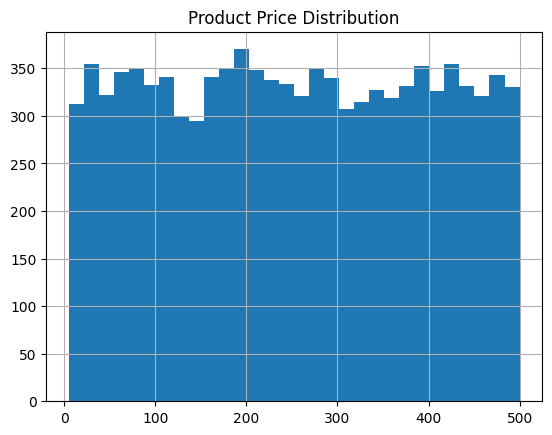

In [65]:
import matplotlib.pyplot as plt

df["Product_Price"].hist(bins=30)
plt.title("Product Price Distribution")
plt.show()

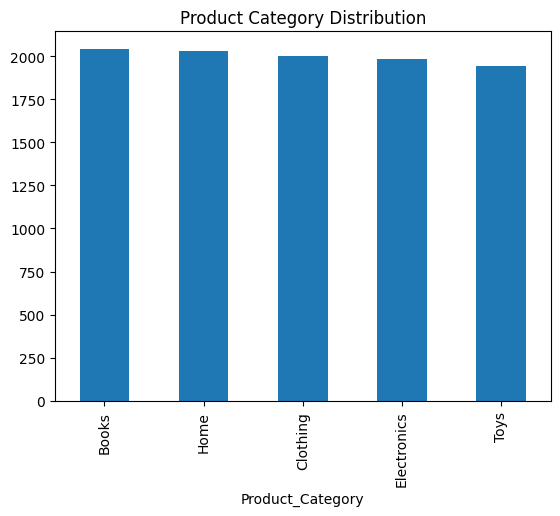

In [66]:
df["Product_Category"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.show()

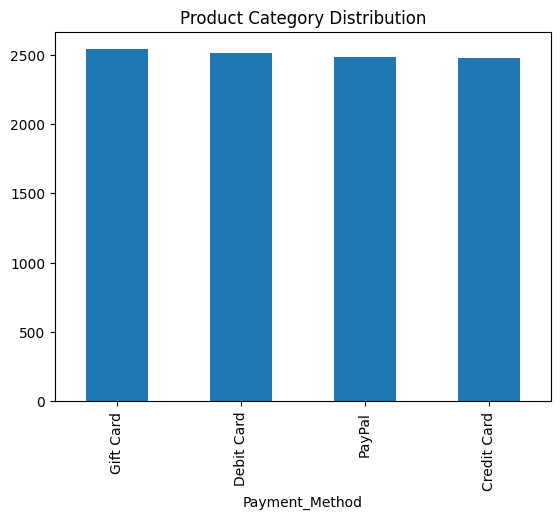

In [67]:
df["Payment_Method"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.show()

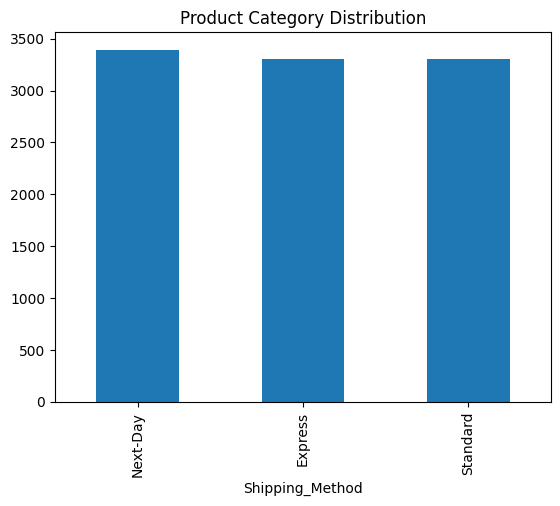

In [68]:
df["Shipping_Method"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.show()

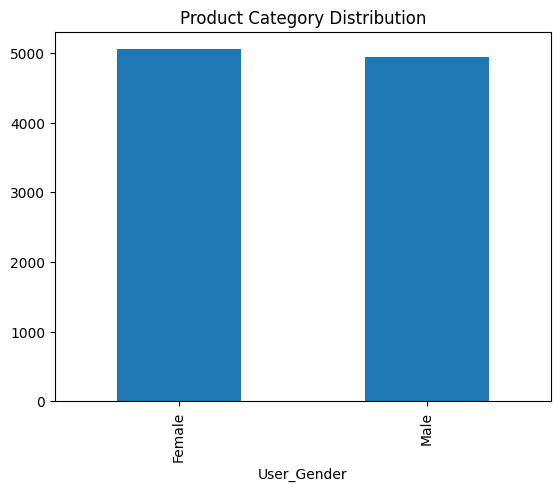

In [69]:
df["User_Gender"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.show()

In [70]:
pd.crosstab(df["Product_Category"], df["Return_Status"])

Return_Status,Not Returned,Returned
Product_Category,,
Books,1007,1034
Clothing,951,1049
Electronics,974,1011
Home,1035,995
Toys,981,963


In [71]:
pd.crosstab(df["Payment_Method"], df["Return_Status"])

Return_Status,Not Returned,Returned
Payment_Method,,
Credit Card,1224,1249
Debit Card,1227,1283
Gift Card,1228,1309
PayPal,1269,1211


In [72]:
df.groupby("Return_Status")["Product_Price"].mean()

Return_Status
Not Returned    252.483664
Returned        252.257304
Name: Product_Price, dtype: float64

In [73]:
df["Return_Status"].value_counts()

Return_Status
Returned        5052
Not Returned    4948
Name: count, dtype: int64

In [74]:
df["Return_Status"].value_counts(normalize=True) * 100

Return_Status
Returned        50.52
Not Returned    49.48
Name: proportion, dtype: float64

In [75]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Price,10000.0,252.369307,142.883865,5.01,128.6500,250.445,377.8375,499.89
Order_Quantity,10000.0,3.006100,1.406791,1.00,2.0000,3.000,4.0000,5.00
Days_to_Return,5052.0,1.453682,297.983208,-719.00,-214.0000,1.000,218.0000,726.00
User_Age,10000.0,44.195000,15.311983,18.00,31.0000,44.000,57.0000,70.00
Discount_Applied,10000.0,24.992162,14.363396,0.00,12.7525,24.840,37.6050,50.00


In [76]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Order_ID
Order_ID
ORD00009983    1
ORD00009982    1
ORD00009981    1
ORD00009980    1
ORD00009979    1
              ..
ORD00000004    1
ORD00000003    1
ORD00000002    1
ORD00000001    1
ORD00000000    1
Name: count, Length: 10000, dtype: int64

Product_ID
Product_ID
PROD00009983    1
PROD00009982    1
PROD00009981    1
PROD00009980    1
PROD00009979    1
               ..
PROD00000004    1
PROD00000003    1
PROD00000002    1
PROD00000001    1
PROD00000000    1
Name: count, Length: 10000, dtype: int64

User_ID
User_ID
USER00009983    1
USER00009982    1
USER00009981    1
USER00009980    1
USER00009979    1
               ..
USER00000004    1
USER00000003    1
USER00000002    1
USER00000001    1
USER00000000    1
Name: count, Length: 10000, dtype: int64

Order_Date
Order_Date
2024-03-14    26
2024-09-22    25
2023-03-09    25
2023-10-04    24
2024-06-09    24
              ..
2024-07-05     5
2024-09-05     5
2024-10-20     5
2024-12-02     4
2024-06-25     2
Name: count, Length: 731,

In [77]:
# Drop leakage columns
drop_cols = [
    "Order_ID",
    "Product_ID",
    "User_ID",
    "Return_Date",
    "Return_Reason",
    "Days_to_Return"
]

df_model = df.drop(columns=drop_cols)

# Separate features and target
X = df_model.drop("Return_Status", axis=1)
y = df_model["Return_Status"]

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
categorical_features = [
    "Product_Category",
    "User_Gender",
    "User_Location",
    "Payment_Method",
    "Shipping_Method"
]

numerical_features = [
    "Product_Price",
    "Order_Quantity",
    "User_Age",
    "Discount_Applied"
]

In [80]:
df["Order_Date"].head()

0    2023-08-05
1    2023-10-09
2    2023-05-06
3    2024-08-29
4    2023-01-16
Name: Order_Date, dtype: object

In [81]:
df_model["Order_Date"] = pd.to_datetime(df_model["Order_Date"])

In [82]:
df_model["Order_Month"] = df_model["Order_Date"].dt.month
df_model["Order_DayOfWeek"] = df_model["Order_Date"].dt.dayofweek
df_model["Order_Quarter"] = df_model["Order_Date"].dt.quarter
df_model["Is_Weekend"] = (
    df_model["Order_Date"].dt.dayofweek >= 5
).astype(int)

In [83]:
df_model.drop("Order_Date", axis=1, inplace=True)

In [84]:
drop_cols = [
    "Order_ID",
    "Product_ID",
    "User_ID",
    "Return_Date",
    "Return_Reason",
    "Days_to_Return"
]

df_model = df.drop(columns=drop_cols)

In [85]:
df_model["Order_Date"] = pd.to_datetime(df_model["Order_Date"])

df_model["Order_Month"] = df_model["Order_Date"].dt.month
df_model["Order_DayOfWeek"] = df_model["Order_Date"].dt.dayofweek
df_model["Order_Quarter"] = df_model["Order_Date"].dt.quarter
df_model["Is_Weekend"] = (
    df_model["Order_Date"].dt.dayofweek >= 5
).astype(int)

df_model.drop("Order_Date", axis=1, inplace=True)

In [86]:
X = df_model.drop("Return_Status", axis=1)
y = df_model["Return_Status"]

In [87]:
y = y.map({
    "Not Returned": 0,
    "Returned": 1
})

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
categorical_features = [
    "Product_Category",
    "User_Gender",
    "User_Location",
    "Payment_Method",
    "Shipping_Method"
]

In [90]:
numerical_features = [
    "Product_Price",
    "Order_Quantity",
    "User_Age",
    "Discount_Applied",
    "Order_Month",
    "Order_DayOfWeek",
    "Order_Quarter",
    "Is_Weekend"
]

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


In [92]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [93]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [94]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [106]:
from sklearn.tree import DecisionTreeClassifier

baseline_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=None
)

In [107]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

In [108]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [109]:
y_pred = pipeline.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(2000,))

In [110]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_prob

array([1., 1., 1., ..., 1., 1., 1.], shape=(2000,))

In [111]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [112]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5
Precision: 0.5050301810865191
Recall   : 0.497029702970297
F1 Score : 0.500998003992016


In [113]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50       990
           1       0.51      0.50      0.50      1010

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



In [114]:
print(confusion_matrix(y_test, y_pred))


[[498 492]
 [508 502]]


In [115]:
from sklearn.metrics import accuracy_score

train_pred = pipeline.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy : 0.5
